Running trained RL controller...


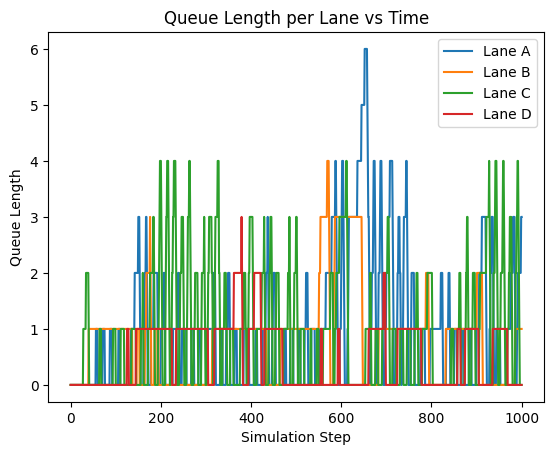


Model Evaluation Result
Total Reward: -6369
Total Queue: 3203


In [ ]:


import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

episode = 1
max_step = 1000

max_green = 30
min_green = 5
max_red = 3

green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0


with open("rl_model_2.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []


traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
phase_prev = traci.trafficlight.getPhase(tls_id)

step =0
done = False
while step < max_step:
    switch = False
    if(step == max_step-1):
        done = True

    discounted_reward = 0
    old_state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = old_state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D

    if old_state in Q:
        action = int(np.argmax(Q[old_state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        if phase in green_ph:
            if(action == 0 ):
                q_values = Q[old_state]
                action = int(np.argmax(q_values[1:]) + 1)
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
                step = step + 1
                switch = True
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
             
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
        
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)

        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)

    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                switch = True
                traci.simulationStep()
                step = step + 1
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
              
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1

    phase_curr = traci.trafficlight.getPhase(tls_id)
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    total_reward += reward
        
    
traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running baseline...


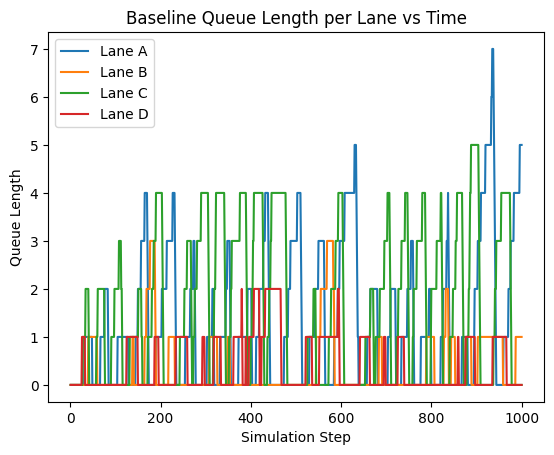


Baseline Result
Total Reward: -9948
Total Queue: 3636


In [2]:
import traci
import matplotlib.pyplot as plt

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

max_step = 1000

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2', '338690994#0_3']

def maxQueueLength(laneList):
    return max(traci.lane.getLastStepHaltingNumber(l) for l in laneList)

def get_state():
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    return (A, B, C, D)

def get_reward(A, B, C, D):
    return -(A*A + B*B + C*C + D*D)

total_reward   = 0
total_ep_queue = 0
step           = 0

A_hist, B_hist, C_hist, D_hist, step_hist = [], [], [], [], []

print("Running baseline...")

traci.start([sumo_exe, "-c", sumo_cfg, "--no-step-log", "--quit-on-end"])

while step < max_step:
    traci.simulationStep()
    step += 1

    A, B, C, D = get_state()

    A_hist.append(A); B_hist.append(B)
    C_hist.append(C); D_hist.append(D)
    step_hist.append(step)

    total_ep_queue += A + B + C + D
    total_reward   += get_reward(A, B, C, D)

traci.close()

plt.figure()
plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")
plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Baseline Queue Length per Lane vs Time")
plt.legend()
plt.show()

print("\nBaseline Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running trained RL controller...


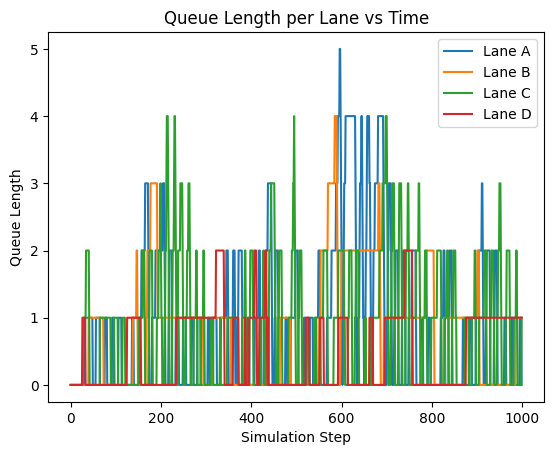


Model Evaluation Result
Total Reward: -5543
Total Queue: 2996


In [6]:


import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

max_step = 1000

max_green = 30
min_green = 5
max_red = 3

green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0


with open("rl_model_1.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []


traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
phase_prev = traci.trafficlight.getPhase(tls_id)

step =0
done = False
while step < max_step:
    switch = False
    if(step == max_step-1):
        done = True
        
    old_state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = old_state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D

    if old_state in Q:
        action = int(np.argmax(Q[old_state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        if phase in green_ph:
            if(action == 0 ):
                q_values = Q[old_state]
                action = int(np.argmax(q_values[1:]) + 1)
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
                step = step + 1
                switch = True
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
             
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
        
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)

        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)

    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                switch = True
                traci.simulationStep()
                step = step + 1
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
              
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1

    phase_curr = traci.trafficlight.getPhase(tls_id)
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    total_reward += reward
        
    
traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running trained RL controller...


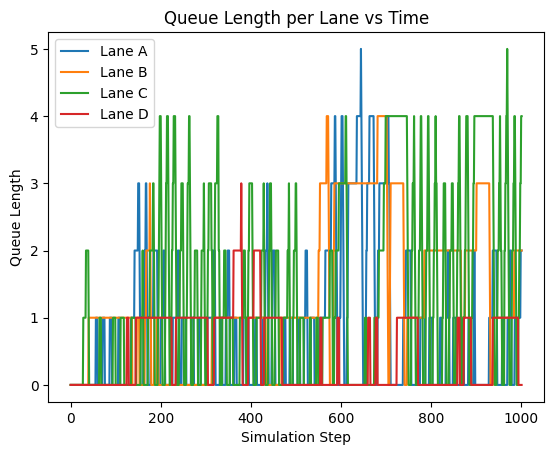


Model Evaluation Result
Total Reward: -9052
Total Queue: 3917


In [7]:


import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

episode = 1
max_step = 1000

max_green = 30
min_green = 5
max_red = 3

green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0


with open("rl_model_2.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []


traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
phase_prev = traci.trafficlight.getPhase(tls_id)

step =0
done = False
while step < max_step:
    switch = False
    if(step == max_step-1):
        done = True

    discounted_reward = 0
    old_state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = old_state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D

    if old_state in Q:
        action = int(np.argmax(Q[old_state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        if phase in green_ph:
            if(action == 0 ):
                action =1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
                step = step + 1
                switch = True
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
             
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
        
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)

        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)

    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                switch = True
                traci.simulationStep()
                step = step + 1
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
              
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1

    phase_curr = traci.trafficlight.getPhase(tls_id)
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    total_reward += reward
        
    
traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running trained RL controller...


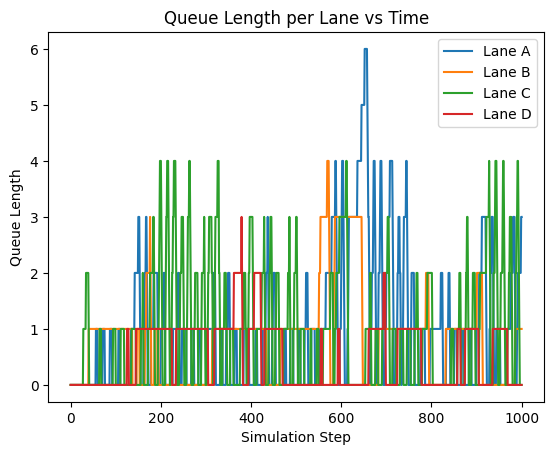


Model Evaluation Result
Total Reward: -6369
Total Queue: 3203


In [1]:


import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo-gui.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

episode = 1
max_step = 1000

max_green = 30
min_green = 5
max_red = 3

green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0


with open("rl_model_2.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []


traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
phase_prev = traci.trafficlight.getPhase(tls_id)

step =0
done = False
while step < max_step:
    switch = False
    if(step == max_step-1):
        done = True

    discounted_reward = 0
    old_state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = old_state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D

    if old_state in Q:
        action = int(np.argmax(Q[old_state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        if phase in green_ph:
            if(action == 0 ):
                q_values = Q[old_state]
                action = int(np.argmax(q_values[1:]) + 1)
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
                step = step + 1
                switch = True
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
             
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
        
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)

        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)

    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                switch = True
                traci.simulationStep()
                step = step + 1
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
              
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1

    phase_curr = traci.trafficlight.getPhase(tls_id)
    new_state = get_state(tls_id)
    reward = get_reward(new_state)
    total_reward += reward
        
    
traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running trained RL controller...


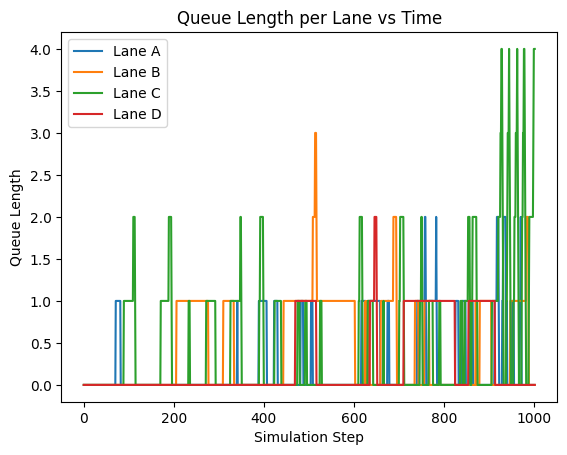


Model Evaluation Result
Total Reward: -1709
Total Queue: 1259


In [ ]:


import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin2.sumocfg"

max_step = 1000

max_green = 30
min_green = 5
max_red = 3

green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0


with open("rl_model_1.pkl", "rb") as f:
    Q_loaded = pickle.load(f)
Q = defaultdict(lambda: np.zeros(4), Q_loaded)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

total_reward = 0
total_ep_queue = 0
step = 0

print("Running trained RL controller...")
step =0
A_hist = []
B_hist = []
C_hist = []
D_hist = []
step_hist = []


traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
phase_prev = traci.trafficlight.getPhase(tls_id)

step =0
done = False
while step < max_step:
    switch = False
    if(step == max_step-1):
        done = True
        
    old_state = get_state(tls_id)
    phase = current_phase(tls_id)
    duration = traci.trafficlight.getSpentDuration(tls_id)
    A, B, C, D, L = old_state

    A_hist.append(A)
    B_hist.append(B)
    C_hist.append(C)
    D_hist.append(D)
    step_hist.append(step)
    total_ep_queue+= A+B+C+D

    if old_state in Q:
        action = int(np.argmax(Q[old_state]))
    else:
        action = 0

    if(mustSwitch(phase,duration)):
        if phase in green_ph:
            if(action == 0 ):
                q_values = Q[old_state]
                action = int(np.argmax(q_values[1:]) + 1)
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                traci.simulationStep()
                step = step + 1
                switch = True
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
             
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

        elif phase in red_ph:
            action = 1
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
        
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)

        if(phase in green_ph):
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhaseDuration(tls_id, 3)

    elif(canRLAct(phase,duration)):
        if(action == 0):
            traci.trafficlight.setPhase(tls_id, phase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)
        else:
            traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            traci.trafficlight.setPhaseDuration(tls_id, 3)
            for i in range(0,3):
                switch = True
                traci.simulationStep()
                step = step + 1
                di_state = get_state(tls_id)
                AA, BB, CC, DD, L = di_state
                A_hist.append(AA)
                B_hist.append(BB)
                C_hist.append(CC)
                D_hist.append(DD)
                step_hist.append(step)
                total_ep_queue+= AA+BB+CC+DD
                reward = get_reward(di_state)
                total_reward += reward
              
            nextPhase = NextPhase(action,phase)
            traci.trafficlight.setPhase(tls_id,nextPhase)
            traci.trafficlight.setPhaseDuration(tls_id, 31)

    traci.simulationStep()
    step += 1

    phase_curr = traci.trafficlight.getPhase(tls_id)
    new_state = get_state(tls_id)






























    
    reward = get_reward(new_state)
    total_reward += reward
        
    
traci.close()
plt.figure()

plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")

plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Queue Length per Lane vs Time")
plt.legend()

plt.show()

print("\nModel Evaluation Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)

Running baseline...


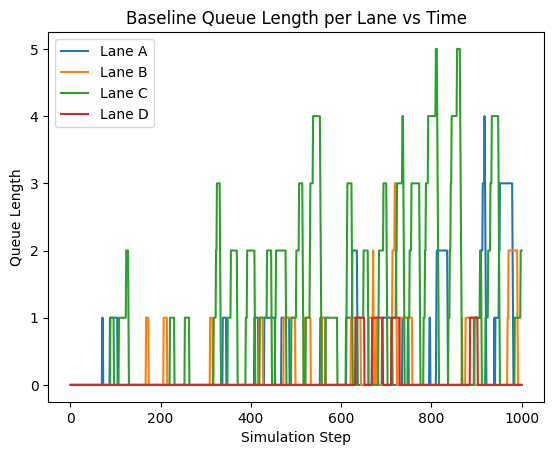


Baseline Result
Total Reward: -3788
Total Queue: 1696


In [2]:
import traci
import matplotlib.pyplot as plt

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin2.sumocfg"

max_step = 1000

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2', '338690994#0_3']

def maxQueueLength(laneList):
    return max(traci.lane.getLastStepHaltingNumber(l) for l in laneList)

def get_state():
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    return (A, B, C, D)

def get_reward(A, B, C, D):
    return -(A*A + B*B + C*C + D*D)

total_reward   = 0
total_ep_queue = 0
step           = 0

A_hist, B_hist, C_hist, D_hist, step_hist = [], [], [], [], []

print("Running baseline...")

traci.start([sumo_exe, "-c", sumo_cfg, "--no-step-log", "--quit-on-end"])

while step < max_step:
    traci.simulationStep()
    step += 1

    A, B, C, D = get_state()

    A_hist.append(A); B_hist.append(B)
    C_hist.append(C); D_hist.append(D)
    step_hist.append(step)

    total_ep_queue += A + B + C + D
    total_reward   += get_reward(A, B, C, D)

traci.close()

plt.figure()
plt.plot(step_hist, A_hist, label="Lane A")
plt.plot(step_hist, B_hist, label="Lane B")
plt.plot(step_hist, C_hist, label="Lane C")
plt.plot(step_hist, D_hist, label="Lane D")
plt.xlabel("Simulation Step")
plt.ylabel("Queue Length")
plt.title("Baseline Queue Length per Lane vs Time")
plt.legend()
plt.show()

print("\nBaseline Result")
print("Total Reward:", total_reward)
print("Total Queue:", total_ep_queue)